In [1]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Load raw (no normalization yet — Step 4 will add it)
train_data = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transforms.ToTensor()  # converts PIL image → tensor [0,1]
)

test_data = datasets.FashionMNIST(
    root='./data',
    train=False,   # PyTorch gives you this for free
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.14MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.6MB/s]


In [2]:
from torch.utils.data import random_split

# Split 60k into 50k train + 10k validation
train_set, val_set = random_split(train_data, [50000, 10000])

# Create DataLoaders (batches data for training)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=64, shuffle=False)

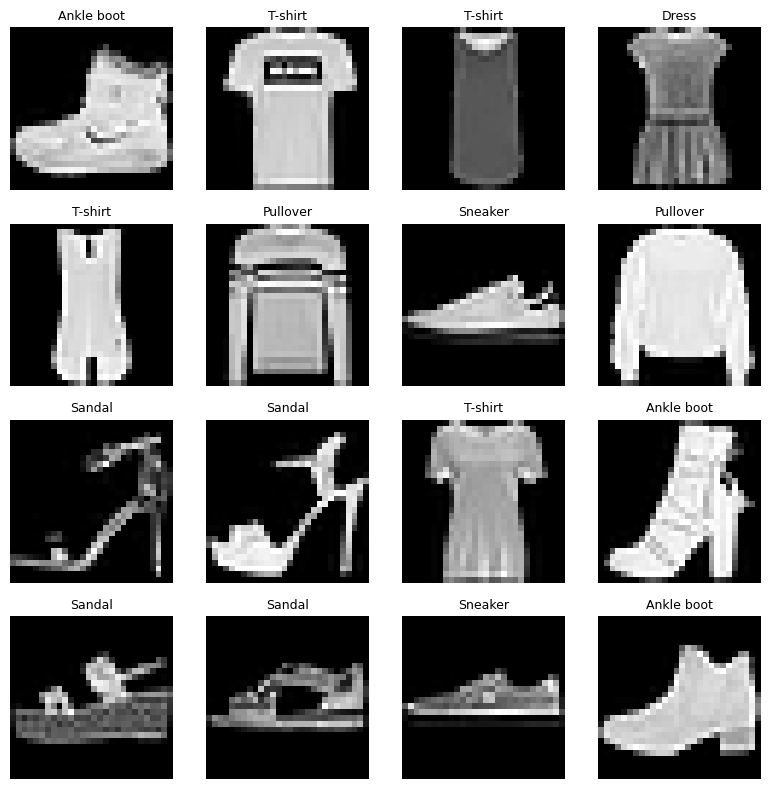

In [3]:
import matplotlib.pyplot as plt

label_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap='gray')  # squeeze removes the channel dim
    ax.set_title(label_names[label], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [4]:
# Update your transform to include normalization
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.2860,),   # Fashion MNIST mean (1 channel)
        std=(0.3530,)    # Fashion MNIST std
    )
])

# Re-load datasets with the updated transform
train_data = datasets.FashionMNIST('./data', train=True,  transform=transform, download=True)
test_data  = datasets.FashionMNIST('./data', train=False, transform=transform, download=True)

# Now pixel values will be roughly in [-1, 1] range
# This helps the optimizer find the minimum faster

Number of classes: 10
Task type: Multiclass classification
Class distribution:
  T-shirt     : 6000 samples
  Trouser     : 6000 samples
  Pullover    : 6000 samples
  Dress       : 6000 samples
  Coat        : 6000 samples
  Sandal      : 6000 samples
  Shirt       : 6000 samples
  Sneaker     : 6000 samples
  Bag         : 6000 samples
  Ankle boot  : 6000 samples


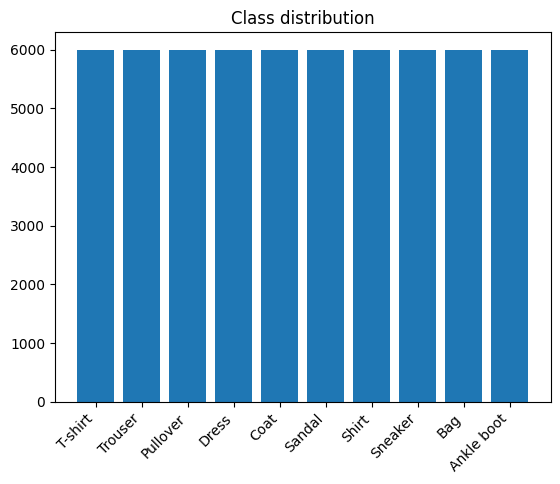

In [8]:
import torch
from collections import Counter

# Get all labels from training set
all_labels = [label for _, label in train_data]
counts = Counter(all_labels)

print(f"Number of classes: {len(counts)}")  # → 10
print("Task type: Multiclass classification")
print("Class distribution:")

for idx, name in enumerate(label_names):
    print(f"  {name:12s}: {counts[idx]} samples")

# Visualize as a bar chart
plt.bar(label_names, [counts[i] for i in range(10)])
plt.xticks(rotation=45, ha='right')
plt.title('Class distribution')
plt.show()

In [9]:
img, label = train_data[0]

In [10]:
print(f"Image shape: {img.shape}")

Image shape: torch.Size([1, 28, 28])


In [11]:
print(f"C={img.shape[0]}, H={img.shape[1]}, W={img.shape[2]}")

C=1, H=28, W=28


In [12]:
# Check the shape of one sample
img, label = train_data[0]
print(f"Image shape: {img.shape}")    # → torch.Size([1, 28, 28])
print(f"C={img.shape[0]}, H={img.shape[1]}, W={img.shape[2]}")

# Formula for Conv2D output size (no padding):
# output_size = (input_size - kernel_size) / stride + 1
#
# Layer stack math for our model:
# Input:          (1,  28, 28)
# Conv2d(1,32,3): (32, 26, 26)  → (28-3)+1 = 26
# MaxPool2d(2):   (32, 13, 13)  → 26/2 = 13
# Conv2d(32,64,3):(64, 11, 11)  → (13-3)+1 = 11
# MaxPool2d(2):   (64,  5,  5)  → 11/2 = 5 (floor)
# Flatten:         64 × 5 × 5  = 1600

flattened_size = 64 * 5 * 5
print(f"Input to first Linear layer: {flattened_size}")  # → 1600

Image shape: torch.Size([1, 28, 28])
C=1, H=28, W=28
Input to first Linear layer: 1600


In [13]:
import torch.nn as nn

class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Feature extraction block
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),        # (32, 26, 26) → (32, 13, 13)

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),        # (64, 11, 11) → (64, 5, 5)
        )

        # Classifier block
        self.classifier = nn.Sequential(
            nn.Flatten(),              # → 1600
            nn.Linear(1600, 256),
            nn.ReLU(),
            nn.Dropout(0.5),         # randomly zeroes 50% of neurons (prevents overfitting)
            nn.Linear(256, 10)       # 10 outputs = 10 clothing classes
        )

    def forward(self, x):
        x = self.conv_block(x)
        return self.classifier(x)  # returns raw logits (not probabilities)

model = FashionCNN()
print(model)

FashionCNN(
  (conv_block): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1600, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [14]:
import torch.optim as optim

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)  # move model to GPU if available on Colab

# Loss function: CrossEntropyLoss for 10-class classification
loss_fn = nn.CrossEntropyLoss()

# Optimizer: Adam with learning rate 0.001
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(f"Training on: {device}")
print(f"Loss function: CrossEntropyLoss (correct for 10 classes)")
print(f"Optimizer: Adam, lr=0.001")

Training on: cpu
Loss function: CrossEntropyLoss (correct for 10 classes)
Optimizer: Adam, lr=0.001


In [15]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()           # activates Dropout
    total_loss, correct = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()             # 1. clear old gradients
        outputs = model(images)           # 2. forward pass
        loss = loss_fn(outputs, labels)   # 3. compute loss
        loss.backward()                   # 4. backpropagate
        optimizer.step()                  # 5. update weights

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)   # pick class with highest logit
        correct += (preds == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy

In [16]:
def evaluate(model, loader, loss_fn, device):
    model.eval()                    # deactivates Dropout
    total_loss, correct = 0, 0

    with torch.no_grad():           # don't compute gradients
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)

# Run the full training + validation loop
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(10):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    vl_loss, vl_acc = evaluate(model, val_loader, loss_fn, device)

    history['train_loss'].append(tr_loss);  history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc);   history['val_acc'].append(vl_acc)

    print(f"Epoch {epoch+1:2d} | Train: {tr_loss:.4f} / {tr_acc:.4f} | Val: {vl_loss:.4f} / {vl_acc:.4f}")

Epoch  1 | Train: 0.5980 / 0.7796 | Val: 0.4100 / 0.8498
Epoch  2 | Train: 0.3962 / 0.8553 | Val: 0.3407 / 0.8764
Epoch  3 | Train: 0.3439 / 0.8734 | Val: 0.3204 / 0.8829
Epoch  4 | Train: 0.3114 / 0.8854 | Val: 0.2871 / 0.8971
Epoch  5 | Train: 0.2870 / 0.8939 | Val: 0.2760 / 0.8994
Epoch  6 | Train: 0.2677 / 0.9018 | Val: 0.2728 / 0.9027
Epoch  7 | Train: 0.2523 / 0.9073 | Val: 0.2627 / 0.9057
Epoch  8 | Train: 0.2373 / 0.9123 | Val: 0.2536 / 0.9071
Epoch  9 | Train: 0.2244 / 0.9182 | Val: 0.2577 / 0.9090
Epoch 10 | Train: 0.2108 / 0.9214 | Val: 0.2514 / 0.9134


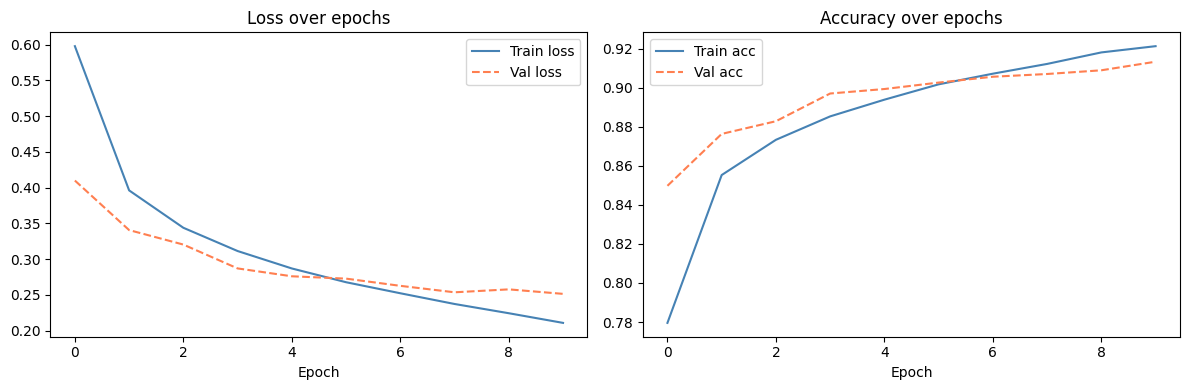

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
ax1.plot(history['train_loss'], label='Train loss', color='steelblue')
ax1.plot(history['val_loss'],   label='Val loss',   color='coral', linestyle='--')
ax1.set_title('Loss over epochs')
ax1.set_xlabel('Epoch')
ax1.legend()

# Accuracy curves
ax2.plot(history['train_acc'], label='Train acc', color='steelblue')
ax2.plot(history['val_acc'],   label='Val acc',   color='coral', linestyle='--')
ax2.set_title('Accuracy over epochs')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

# What to look for:
# ✓ Both curves close together → good generalization
# ✗ Train drops, val rises → overfitting (add Dropout, reduce model size)
# ✗ Both stay high → underfitting (more epochs, bigger model, lower lr)

In [20]:
# Final evaluation on test set (only done ONCE at the end)
test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)
print(f"{'='*40}")
print(f"FINAL TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"FINAL TEST LOSS:     {test_loss:.4f}")


# Benchmark:
# Random guessing:  10%   (1/10 classes)
# Good baseline:    88%+
# State of the art: ~96%+ (needs deeper networks, data augmentation)

FINAL TEST ACCURACY: 0.9116 (91.16%)
FINAL TEST LOSS:     0.2493


              precision    recall  f1-score   support

     T-shirt       0.82      0.91      0.86      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.86      0.87      0.87      1000
       Dress       0.89      0.94      0.91      1000
        Coat       0.86      0.86      0.86      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.80      0.66      0.72      1000
     Sneaker       0.95      0.98      0.96      1000
         Bag       0.98      0.99      0.98      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



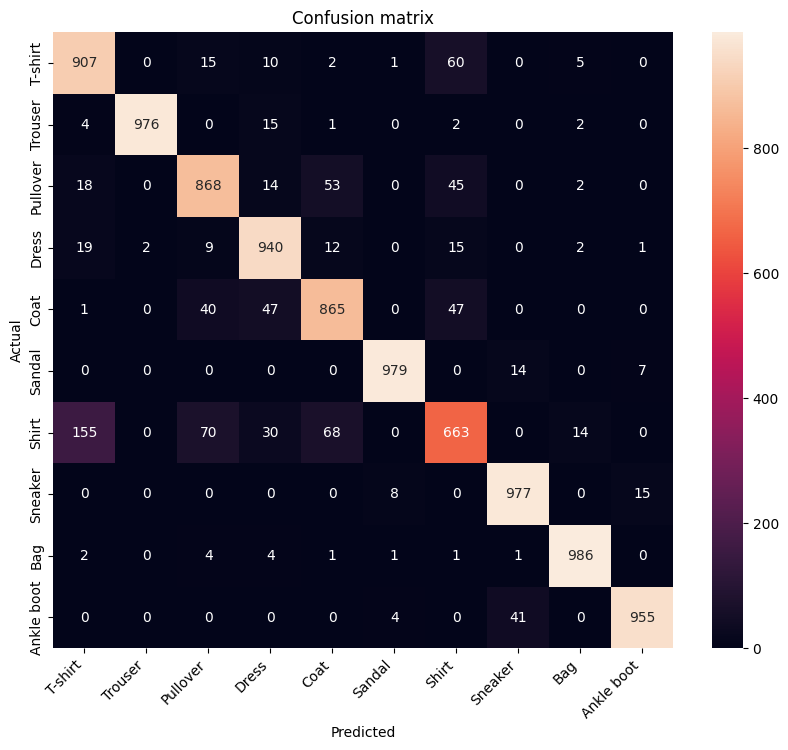

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# Per-class report
print(classification_report(all_labels, all_preds, target_names=label_names))

# Confusion matrix heatmap
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.show()

In [22]:
# Install if needed: !pip install torchsummary
!pip install torchsummary
from torchsummary import summary

# Pass the input shape (C, H, W) — NOT batch size
summary(model, input_size=(1, 28, 28))

# Output will show:
# Layer name | Output Shape | Param #
# Conv2d-1   | [32, 26, 26] | 320
# MaxPool2d  | [32, 13, 13] | 0      ← pooling has no learnable params
# ...
# Total params: ~XXX,XXX
# Trainable params: same (all are trainable here)
#
# Rule of thumb:
# < 1M params  → lightweight (mobile-friendly)
# 1–10M params → medium (typical CNN)
# 100M+ params → heavy (needs GPU, not for edge devices)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 26, 26]             320
              ReLU-2           [-1, 32, 26, 26]               0
         MaxPool2d-3           [-1, 32, 13, 13]               0
            Conv2d-4           [-1, 64, 11, 11]          18,496
              ReLU-5           [-1, 64, 11, 11]               0
         MaxPool2d-6             [-1, 64, 5, 5]               0
           Flatten-7                 [-1, 1600]               0
            Linear-8                  [-1, 256]         409,856
              ReLU-9                  [-1, 256]               0
          Dropout-10                  [-1, 256]               0
           Linear-11                   [-1, 10]           2,570
Total params: 431,242
Trainable params: 431,242
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/

In [23]:
# Save only the weights (recommended practice)
torch.save(model.state_dict(), 'fashion_cnn.pth')
print("Model saved to fashion_cnn.pth")

# To reload later:
loaded_model = FashionCNN()                              # recreate the architecture
loaded_model.load_state_dict(torch.load('fashion_cnn.pth'))
loaded_model.eval()

# Pro tip: save the BEST validation model, not just the final one
# Add this inside your training loop:
# if val_acc > best_val_acc:
#     best_val_acc = val_acc
#     torch.save(model.state_dict(), 'best_model.pth')

# On Colab: download to your machine
from google.colab import files
files.download('fashion_cnn.pth')

Model saved to fashion_cnn.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>